In [2]:
import geopandas as gpd
import rasterio
import pandas as pd

print("Notebook funcionando 🚀")


Notebook funcionando 🚀


In [3]:
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

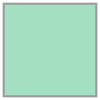

In [5]:
# Coordenadas del polígono (x, y)
coords = [(0,0), (0,5), (5,5), (5,0)]

# Crear el polígono
poligono = Polygon(coords)

poligono


In [7]:
gdf = gpd.GeoDataFrame(
    {"poligono": ["Area_1"]},
    geometry=[poligono],
    crs="EPSG:4326"
)

gdf


,poligono,geometry
0,Area_1,"POLYGON ((0 0, 0 5, 5 5, 5 0, 0 0))"


In [8]:
gdf["area"] = gdf.area
gdf


C:\Users\valeriaMadariagacuel\AppData\Local\Temp\ipykernel_18204\4147130574.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area"] = gdf.area


,poligono,geometry,area
0,Area_1,"POLYGON ((0 0, 0 5, 5 5, 5 0, 0 0))",25.0


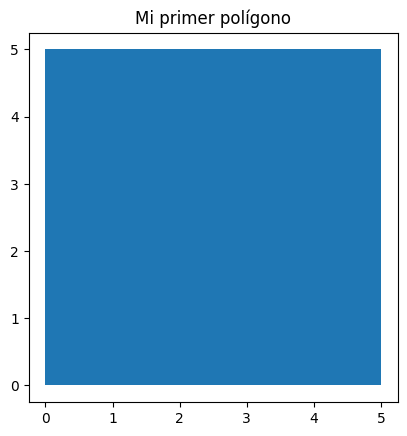

In [9]:
gdf.plot()
plt.title("Mi primer polígono")
plt.show()


In [10]:
gdf_ctm = gdf.to_crs("EPSG:9377")
gdf_ctm["area_m2"] = gdf_ctm.area
gdf_ctm


,poligono,geometry,area,area_m2
0,Area_1,"POLYGON ((17217963.904 1558049.531, 16930137.7...",25.0,5.248498e+12


#Raster

In [11]:
import numpy as np
import matplotlib.pyplot as plt


In [12]:
# Crear una matriz 10x10 con valores de elevación
dem = np.array([
    [100,102,104,106,108,110,112,114,116,118],
    [101,103,105,107,109,111,113,115,117,119],
    [102,104,106,108,110,112,114,116,118,120],
    [103,105,107,109,111,113,115,117,119,121],
    [104,106,108,110,112,114,116,118,120,122],
    [105,107,109,111,113,115,117,119,121,123],
    [106,108,110,112,114,116,118,120,122,124],
    [107,109,111,113,115,117,119,121,123,125],
    [108,110,112,114,116,118,120,122,124,126],
    [109,111,113,115,117,119,121,123,125,127]
])

dem


array([[100, 102, 104, 106, 108, 110, 112, 114, 116, 118],
       [101, 103, 105, 107, 109, 111, 113, 115, 117, 119],
       [102, 104, 106, 108, 110, 112, 114, 116, 118, 120],
       [103, 105, 107, 109, 111, 113, 115, 117, 119, 121],
       [104, 106, 108, 110, 112, 114, 116, 118, 120, 122],
       [105, 107, 109, 111, 113, 115, 117, 119, 121, 123],
       [106, 108, 110, 112, 114, 116, 118, 120, 122, 124],
       [107, 109, 111, 113, 115, 117, 119, 121, 123, 125],
       [108, 110, 112, 114, 116, 118, 120, 122, 124, 126],
       [109, 111, 113, 115, 117, 119, 121, 123, 125, 127]])

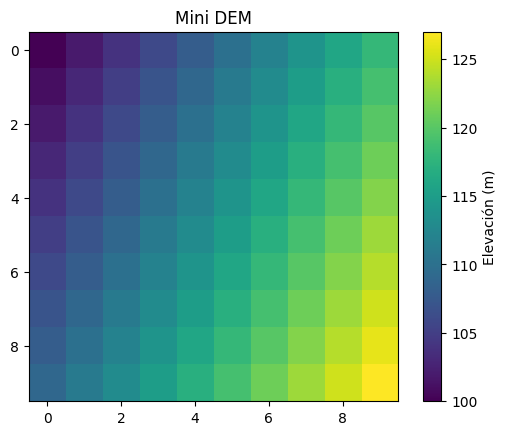

In [13]:
plt.imshow(dem)
plt.colorbar(label="Elevación (m)")
plt.title("Mini DEM")
plt.show()


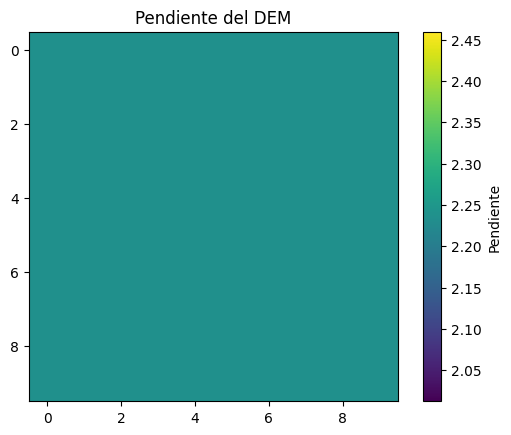

In [14]:
# Calcular gradientes en x e y
grad_y, grad_x = np.gradient(dem)

# Pendiente aproximada
pendiente = np.sqrt(grad_x**2 + grad_y**2)

plt.imshow(pendiente)
plt.colorbar(label="Pendiente")
plt.title("Pendiente del DEM")
plt.show()
